# 13 - Outline Areas: the shoelace formula, its gradient, and its Hessian

A **closed outline** (or *chamber*) is a loop of edges through a shared set of 2D
vertices. simkit measures the **signed area** each loop encloses with
`outline_areas`, and provides its first and second derivatives with
`outline_areas_gradient` and `outline_areas_hessian`. This notebook walks through
all three, top to bottom:

1. **Known areas.** Measure a triangle, a square, and a regular polygon, and watch
   the polygon's area converge to $\pi r^2$ as it gains sides.
2. **Orientation = sign.** Walk the same loop clockwise vs counter-clockwise and
   watch the sign flip. This is why simkit keeps the *signed* area: it is a smooth
   polynomial of the vertices, differentiable everywhere.
3. **The gradient inflates the shape.** $\nabla A$ is the direction each vertex
   should move to grow the area; it points along the outward normal. We draw that
   field, then follow it to inflate a star while the area climbs monotonically.
4. **Checking the derivatives.** The analytic gradient and (constant) Hessian are
   compared against finite differences, the same checks the unit tests make.

In [1]:
# --- make the *local* simkit (this repo) importable, ahead of any installed copy ---
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

import simkit
import utils

os.makedirs("media", exist_ok=True)

# A small consistent palette.
POS_C = "#2a9d8f"   # positive / CCW area
NEG_C = "#e76f51"   # negative / CW area
EDGE_C = "#264653"
GRAD_C = "#e9c46a"


def regular_polygon(n, r=1.0, center=(0.0, 0.0)):
    # n vertices spaced counter-clockwise on a circle of radius r.
    theta = np.linspace(0.0, 2.0 * np.pi, n, endpoint=False)
    return np.column_stack([center[0] + r * np.cos(theta),
                            center[1] + r * np.sin(theta)])


def draw_outline(ax, X, color, fill=True, lw=2.5):
    # Draw a closed outline (and optionally fill it) on ax.
    loop = np.vstack([X, X[0]])
    if fill:
        ax.fill(X[:, 0], X[:, 1], color=color, alpha=0.18, zorder=1)
    ax.plot(loop[:, 0], loop[:, 1], "-o", color=color, lw=lw, ms=5, zorder=3)

## 1 - Known areas: the shoelace formula on shapes we can check by hand

For a closed loop of vertices the **signed** area is the shoelace (Gauss) formula

$$ A = \tfrac{1}{2} \sum_{(i,j)\in E} \big(x_i\, y_j - x_j\, y_i\big). $$

Each term is twice the signed area of the triangle (origin, $p_i$, $p_j$); summing
around the loop, the parts outside the polygon cancel and only the enclosed area
survives. We test it on three shapes whose area we already know:

* right triangle with legs 1 &nbsp;&rarr;&nbsp; $A = \tfrac12$
* unit square &nbsp;&rarr;&nbsp; $A = 1$
* regular $n$-gon of radius $r$ &nbsp;&rarr;&nbsp; $A = \tfrac12 n r^2 \sin(2\pi/n)$

That last one is the nicest: a regular polygon is just a circle we have not
finished drawing, so its shoelace area marches up to $\pi r^2$ as $n$ grows.

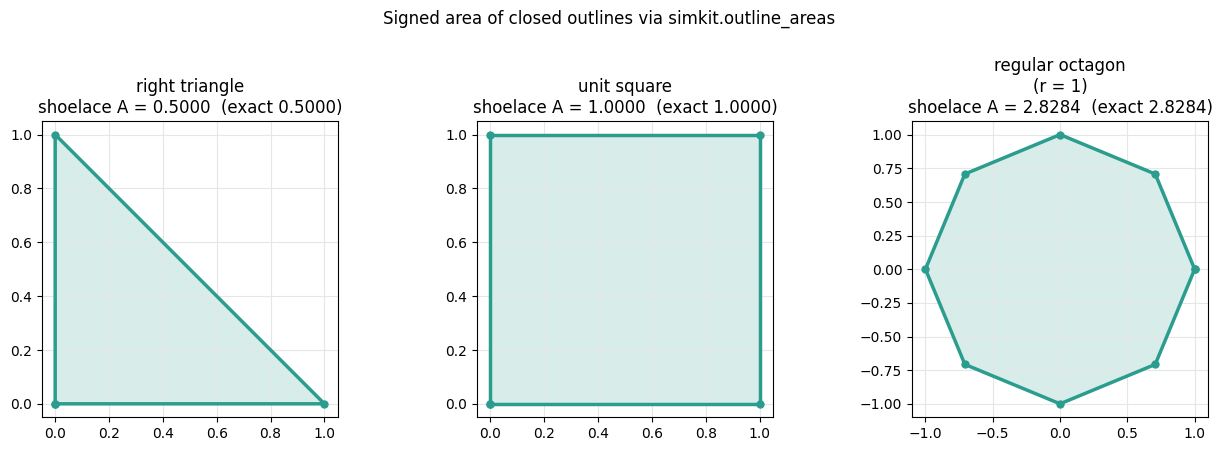

In [2]:
shapes = [
    ("right triangle", np.array([[0.0, 0.0], [1.0, 0.0], [0.0, 1.0]]), 0.5),
    ("unit square", np.array([[0.0, 0.0], [1.0, 0.0], [1.0, 1.0], [0.0, 1.0]]), 1.0),
    ("regular octagon\n(r = 1)", regular_polygon(8, r=1.0),
     0.5 * 8 * 1.0 ** 2 * np.sin(2 * np.pi / 8)),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, (name, X, exact) in zip(axes, shapes):
    E = simkit.closed_polyline(X)
    A = simkit.outline_areas(X, [E])[0]
    draw_outline(ax, X, POS_C)
    utils.setup_axes(ax, title=f"{name}\nshoelace A = {A:.4f}  (exact {exact:.4f})")
fig.suptitle("Signed area of closed outlines via simkit.outline_areas", y=1.03)
fig.tight_layout()
fig.savefig("media/13_known_areas.png", dpi=130, bbox_inches="tight")
plt.show()

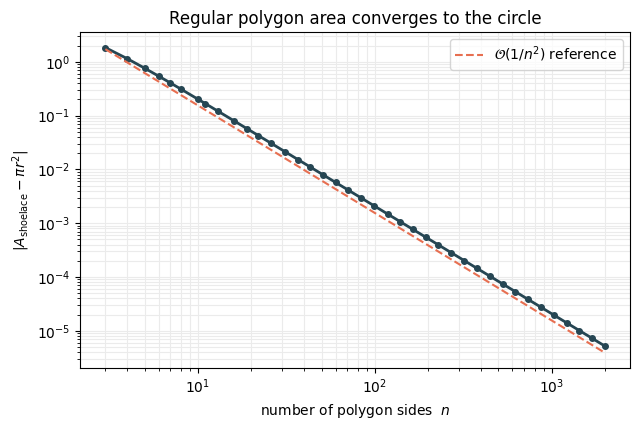

In [3]:
# Convergence of the regular n-gon area to the circle pi r^2.
r = 1.0
ns = np.unique(np.round(np.logspace(np.log10(3), np.log10(2000), 40)).astype(int))
err = [abs(simkit.outline_areas(regular_polygon(int(n), r=r),
                                [simkit.closed_polyline(regular_polygon(int(n), r=r))])[0]
           - np.pi * r ** 2) for n in ns]

fig, ax = plt.subplots(figsize=(6.5, 4.4))
ax.loglog(ns, err, "-o", color=EDGE_C, ms=4, lw=2)
ax.loglog(ns, 0.5 * np.pi ** 3 / ns ** 2, "--", color=NEG_C, lw=1.5,
          label=r"$\mathcal{O}(1/n^2)$ reference")
ax.set_xlabel("number of polygon sides  $n$")
ax.set_ylabel(r"$|A_{\mathrm{shoelace}} - \pi r^2|$")
ax.set_title("Regular polygon area converges to the circle")
ax.grid(True, which="both", color="0.92")
ax.legend()
fig.tight_layout()
fig.savefig("media/13_circle_convergence.png", dpi=130, bbox_inches="tight")
plt.show()

## 2 - Orientation is the sign of the area

The shoelace area is **signed**: traverse a loop counter-clockwise and you get a
positive number, traverse the *exact same loop* clockwise and you get its negative.
simkit deliberately keeps this sign instead of taking $|A|$, because the signed area
is a smooth polynomial in the vertex coordinates &mdash; so its gradient and Hessian
(sections 3-4) are exact everywhere, including the degenerate $A = 0$ case where
$|A|$ has a non-differentiable kink.

counter-clockwise A = +1.600,  clockwise A = -1.600


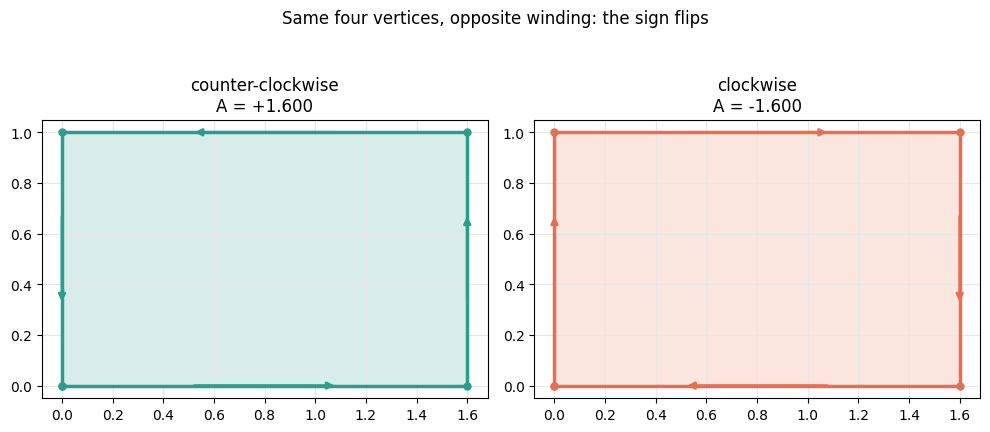

In [4]:
X = np.array([[0.0, 0.0], [1.6, 0.0], [1.6, 1.0], [0.0, 1.0]])
E_ccw = simkit.closed_polyline(X)
E_cw = E_ccw[::-1, ::-1]                 # same loop, walked the other way

A_ccw = simkit.outline_areas(X, [E_ccw])[0]
A_cw = simkit.outline_areas(X, [E_cw])[0]
print(f"counter-clockwise A = {A_ccw:+.3f},  clockwise A = {A_cw:+.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.4))
for ax, (E, A, c, label) in zip(
    axes,
    [(E_ccw, A_ccw, POS_C, "counter-clockwise"),
     (E_cw, A_cw, NEG_C, "clockwise")],
):
    draw_outline(ax, X, c)
    for a, b in E:                       # arrowheads showing the winding direction
        mid = 0.5 * (X[a] + X[b])
        d = X[b] - X[a]
        ax.annotate("", xy=mid + 0.18 * d, xytext=mid - 0.18 * d,
                    arrowprops=dict(arrowstyle="-|>", color=c, lw=2))
    utils.setup_axes(ax, title=f"{label}\nA = {A:+.3f}")
fig.suptitle("Same four vertices, opposite winding: the sign flips", y=1.03)
fig.tight_layout()
fig.savefig("media/13_orientation_sign.png", dpi=130, bbox_inches="tight")
plt.show()

## 3 - The gradient inflates the shape

`outline_areas_gradient` returns $\partial A/\partial x$ for every vertex of the
loop, stacked as `[dx0, dy0, dx1, dy1, ...]`. Geometrically

$$ \frac{\partial A}{\partial x_i} = \tfrac12 (y_{i+1} - y_{i-1}), \qquad
   \frac{\partial A}{\partial y_i} = -\tfrac12 (x_{i+1} - x_{i-1}), $$

so the area grows fastest when vertex $i$ moves along its **outward normal**, by an
amount proportional to the length of its two incident edges. The gradient field is
therefore a ring of outward arrows.

Follow that field &mdash; $x \leftarrow x + \mathrm{d}t\,\nabla A$ &mdash; and the
loop inflates: every step is guaranteed to increase the area because we move
straight uphill on $A$. We start from a spiky star so the inflation is dramatic.

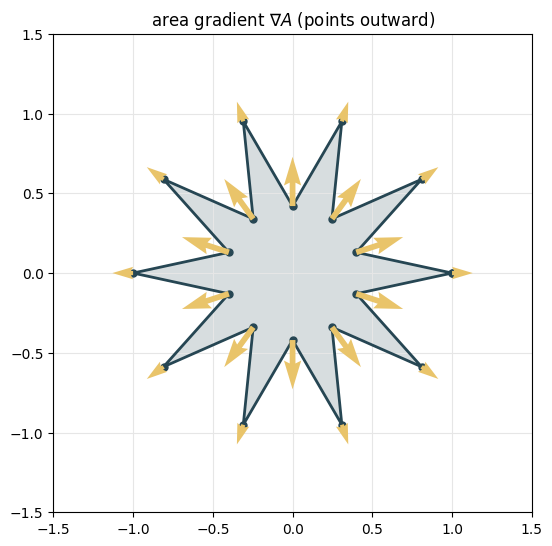

In [5]:
# A 10-point star: alternate far / near radii.
n_arms = 10
ang = np.linspace(0.0, 2.0 * np.pi, 2 * n_arms, endpoint=False)
rad = np.where(np.arange(2 * n_arms) % 2 == 0, 1.0, 0.42)
X0 = np.column_stack([rad * np.cos(ang), rad * np.sin(ang)])
E = simkit.closed_polyline(X0)

# Per-vertex area gradient reshaped to (n, 2) in this loop's vertex order.
g = simkit.outline_areas_gradient(X0, [E])[0].reshape(-1, 2)

fig, ax = plt.subplots(figsize=(5.6, 5.6))
draw_outline(ax, X0, EDGE_C, fill=True, lw=2)
ax.quiver(X0[:, 0], X0[:, 1], g[:, 0], g[:, 1],
          color=GRAD_C, angles="xy", scale_units="xy", scale=1.0,
          width=0.012, zorder=5)
utils.setup_axes(ax, (-1.5, 1.5), (-1.5, 1.5),
                 title="area gradient $\\nabla A$ (points outward)")
fig.tight_layout()
fig.savefig("media/13_gradient_field.png", dpi=130, bbox_inches="tight")
plt.show()

In [6]:
# Gradient ascent: inflate the star, recording the area at every step.
dt, n_steps = 0.08, 90
states = [X0.copy()]
areas = [simkit.outline_areas(X0, [E])[0]]
X = X0.copy()
for _ in range(n_steps):
    g = simkit.outline_areas_gradient(X, [E])[0].reshape(-1, 2)
    X = X + dt * g                       # one step straight uphill on A
    states.append(X.copy())
    areas.append(simkit.outline_areas(X, [E])[0])
print(f"area grew from {areas[0]:.3f} to {areas[-1]:.3f} "
      f"(monotone: {np.all(np.diff(areas) > 0)})")

area grew from 1.298 to 126.337 (monotone: True)



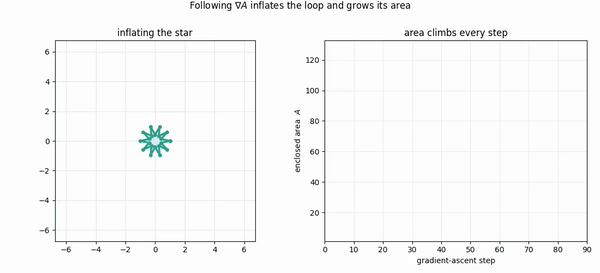

In [7]:
# Animate the inflation with the area curve filling in beside it.
fig, (ax_s, ax_a) = plt.subplots(1, 2, figsize=(11, 5))
lim = 1.05 * np.max(np.abs(states[-1]))
utils.setup_axes(ax_s, (-lim, lim), (-lim, lim), title="inflating the star")
(loop_line,) = ax_s.plot([], [], "-o", color=POS_C, lw=2.5, ms=4)
fill_holder = {"p": None}

ax_a.set_xlim(0, n_steps)
ax_a.set_ylim(areas[0] * 0.9, areas[-1] * 1.05)
ax_a.set_xlabel("gradient-ascent step")
ax_a.set_ylabel("enclosed area  $A$")
ax_a.set_title("area climbs every step")
ax_a.grid(True, color="0.92")
(area_line,) = ax_a.plot([], [], color=POS_C, lw=2.5)

def update(k):
    Xk = states[k]
    loop = np.vstack([Xk, Xk[0]])
    loop_line.set_data(loop[:, 0], loop[:, 1])
    if fill_holder["p"] is not None:
        fill_holder["p"].remove()
    fill_holder["p"] = ax_s.fill(Xk[:, 0], Xk[:, 1], color=POS_C, alpha=0.18, zorder=1)[0]
    area_line.set_data(np.arange(k + 1), areas[:k + 1])
    return loop_line, area_line

anim = FuncAnimation(fig, update, frames=len(states), interval=50, blit=False)
fig.suptitle("Following $\\nabla A$ inflates the loop and grows its area", y=1.0)
fig.tight_layout()
utils.save_anim(anim, "media/13_inflate.mp4", fps=20)
plt.close(fig)
utils.show_anim(anim)

## 4 - Checking the gradient and Hessian against finite differences

The analytic derivatives should match a brute-force central finite difference of
`outline_areas`. We show that as heatmaps: analytic vs FD, plus the tiny residual.
The Hessian is especially clean &mdash; the signed area is **bilinear** in the
coordinates, so $\partial^2 A/\partial x^2$ is a *constant* matrix that only couples
the $x$ of one endpoint to the $y$ of the other (the checkerboard pattern below),
and it does not depend on where the vertices are at all.

max |grad - fd| = 6.78e-10
max |Hess - fd| = 5.14e-10


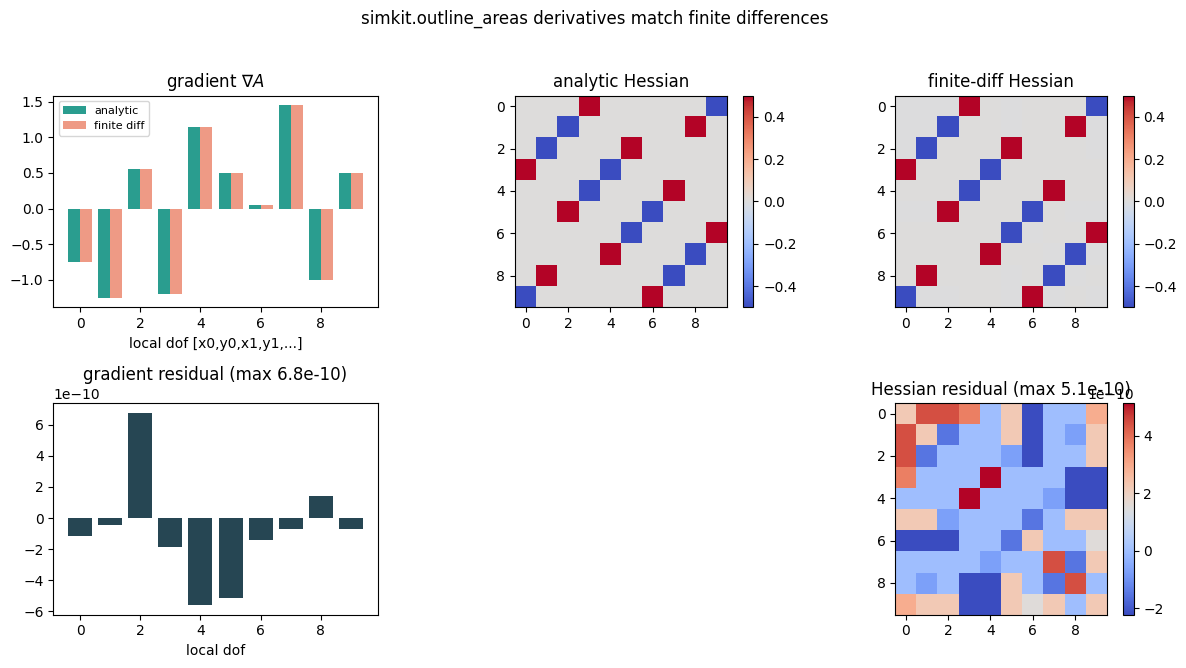

In [8]:
X = np.array([[0.0, 0.0], [2.0, -0.3], [2.4, 1.1],
              [1.0, 2.0], [-0.5, 1.2]])          # irregular pentagon
E = simkit.closed_polyline(X)
z = X.flatten()

def area_flat(zz):                                # all verts in one loop ->
    return simkit.outline_areas(zz.reshape(-1, 2), [E])   # local dofs == X.flatten()

g = simkit.outline_areas_gradient(X, [E])[0].flatten()
g_fd = simkit.gradient_cfd(area_flat, z, 1e-6).flatten()
H = simkit.outline_areas_hessian(X, [E])[0]
H_fd = simkit.hessian_cfd(area_flat, z, 1e-3).reshape(H.shape)
print(f"max |grad - fd| = {np.max(np.abs(g - g_fd)):.2e}")
print(f"max |Hess - fd| = {np.max(np.abs(H - H_fd)):.2e}")

fig = plt.figure(figsize=(12, 6.5))
ax_g = fig.add_subplot(2, 3, 1)
idx = np.arange(len(g))
ax_g.bar(idx - 0.2, g, width=0.4, color=POS_C, label="analytic")
ax_g.bar(idx + 0.2, g_fd, width=0.4, color=NEG_C, alpha=0.7, label="finite diff")
ax_g.set_title("gradient $\\nabla A$"); ax_g.set_xlabel("local dof [x0,y0,x1,y1,...]")
ax_g.legend(fontsize=8)

ax_gr = fig.add_subplot(2, 3, 4)
ax_gr.bar(idx, g - g_fd, color=EDGE_C)
ax_gr.set_title(f"gradient residual (max {np.max(np.abs(g-g_fd)):.1e})")
ax_gr.set_xlabel("local dof")

vmax = max(np.max(np.abs(H)), 1e-9)
for col, (M, title) in enumerate([(H, "analytic Hessian"), (H_fd, "finite-diff Hessian")]):
    ax = fig.add_subplot(2, 3, 2 + col)
    im = ax.imshow(M, cmap="coolwarm", vmin=-vmax, vmax=vmax)
    ax.set_title(title); fig.colorbar(im, ax=ax, fraction=0.046)
ax_hr = fig.add_subplot(2, 3, 6)
im = ax_hr.imshow(H - H_fd, cmap="coolwarm")
ax_hr.set_title(f"Hessian residual (max {np.max(np.abs(H-H_fd)):.1e})")
fig.colorbar(im, ax=ax_hr, fraction=0.046)

fig.suptitle("simkit.outline_areas derivatives match finite differences", y=1.02)
fig.tight_layout()
fig.savefig("media/13_derivative_checks.png", dpi=130, bbox_inches="tight")
plt.show()